
# Universitat Oberta de Catalunya  
## Grado en Ingeniería Informática  
### Trabajo Final de Grado (TFG)

---

## Sistema de recomendaciones basado en técnicas de aprendizaje automático para ampliar la exploración de géneros musicales 
**Autor:** Marc Fernández Pereira  
**Bajo supervisión de:** Dra. María Moreno de Castro  
**Área:** Inteligencia Artificial  
**Semestre:** Otoño 2025  



---

## Índice



In [30]:
# Este import centraliza todas las librerías estándar, scikit-learn y funciones personalizadas
from imports import *

### Funciones

In [31]:
# Paleta fija con colores diferenciados (hasta 10 clústeres).
palette_colors = [
    '#1f77b4',  # azul
    '#ff7f0e',  # naranja
    '#2ca02c',  # verde
    '#d62728',  # rojo
    '#9467bd',  # morado
    '#8c564b',  # marrón
    '#17becf',  # cian
    '#7f7f7f',  # gris
    '#bcbd22',  # oliva
    '#000000'   # negro
]


def cluster_silhouette_score(model, X, sample_size=10000):
    """
    Calcula el coeficiente de Silhouette como métrica de validación interna para clustering.
    Adaptada para su uso con permutation_importance de scikit-learn.
    
    :param model: Modelo de clustering entrenado (KMeans, GMM, etc.)
    :param X: Matriz de características (n_samples, n_features)
    :param sample_size: Tamaño de muestra para reducir coste computacional (por defecto 10000)
    :return: Coeficiente de Silhouette (valores entre -1 y 1)
    """
    labels = model.predict(X)
    return silhouette_score(X, labels, sample_size=sample_size, random_state=42)



### Carga de datos y modelos entrenados en el cuaderno de clustering


In [32]:
# Cargar dataset preprocesado
df = pd.read_csv('spotify_tracks_clean.csv')

# Cargar scaler y PCA
scaler = joblib.load('scaler_object.pkl')
pca = joblib.load('models/pca_95var.pkl')

# Variables utilizadas en el modelado de clustering
selected_vars = ['energy', 'acousticness', 'danceability', 'valence', 'tempo', 'liveness']

# Matriz de características original
X = df[selected_vars].copy()

# Datos estandarizados (mismas variables que en el cuaderno de modelado)
df_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=[f"{col}_norm" for col in selected_vars]
)

# Proyección PCA (mismas componentes que en el cuaderno de modelado)
X_pca = pca.transform(df_scaled)
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Cargar modelos de clustering
kmeans_k7_estand = joblib.load('models/kmeans_k7_estand.pkl')
kmeans_k4_pca = joblib.load('models/kmeans_k4_pca.pkl')
kmeans_k7_pca = joblib.load('models/kmeans_k7_pca.pkl')
gmm_n20_pca = joblib.load('models/gmm_n20_pca.pkl')


# 4. Explicabilidad (XAI)



## 4.1 Permutation Feature Importance

### 4.1.1 Definición de la función de scoring basada en Silhouette

TODO NOMBRAR RECURSOS 45 ,46 

In [33]:

sil_k4 = cluster_silhouette_score(kmeans_k4_pca, X_pca)
sil_k7 = cluster_silhouette_score(kmeans_k7_pca, X_pca)

print(f"Silhouette K-Means k=4: {sil_k4:.3f}")
print(f"Silhouette K-Means k=7: {sil_k7:.3f}")

c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Silhouette K-Means k=4: 0.250
Silhouette K-Means k=7: 0.197


### 4.1.2 Cálculo de la importancia de variables para K-Means k=4



In [34]:
# Tomamos una muestra representativa del conjunto de datos para acelerar el proceso ya que computacionalmente es muy costosa
X_pca_sample = X_pca_df.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=4 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k4_pca.pkl'):
    p_importance_k4_pca = joblib.load('resultados_explicabilidad/p_importance_k4_pca.pkl')
else:
    p_importance_k4_pca = permutation_importance(
        kmeans_k4_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )


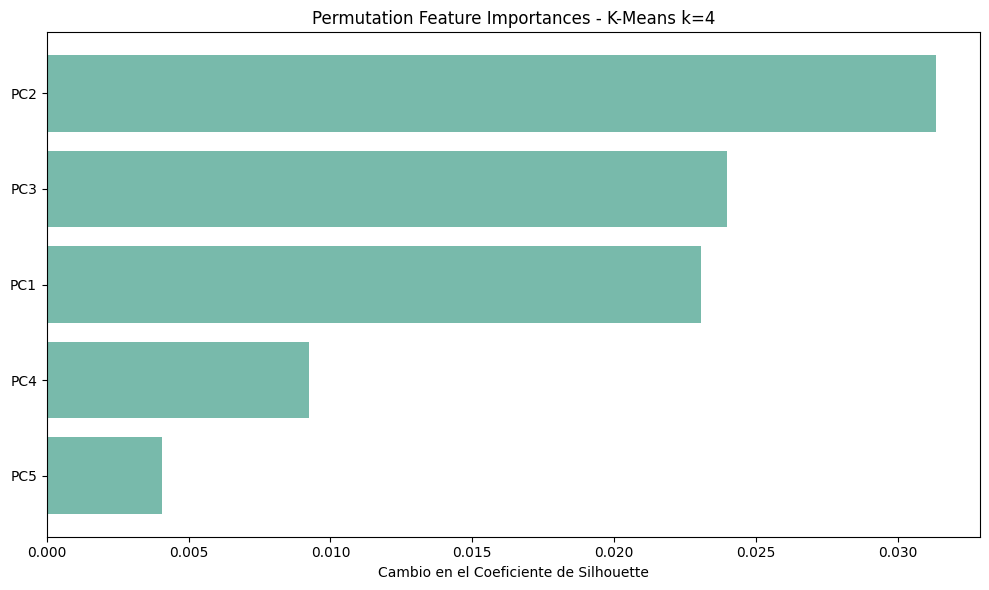

In [35]:
# Extraemos nombres de las features (componentes principales en este caso)
feature_names = X_pca_sample.columns.values

# Ordenación en función de la importancia
sorted_indices_perm = np.argsort(np.abs(p_importance_k4_pca.importances_mean))

# Gráfico de barras para mostrar resultados
plt.figure(figsize=(10, 6))

plt.barh(range(len(feature_names)), p_importance_k4_pca.importances_mean[sorted_indices_perm], color='#69B3A2', alpha=0.9)
plt.yticks(range(len(feature_names)), feature_names[sorted_indices_perm])
plt.title("Permutation Feature Importances - K-Means k=4")
plt.xlabel("Cambio en el Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

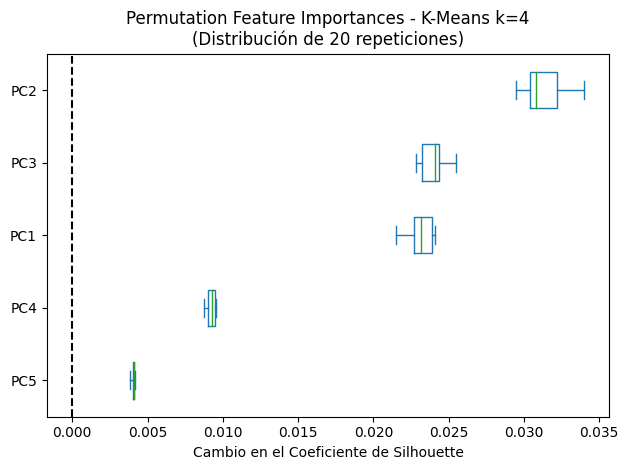

In [36]:
# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx = p_importance_k4_pca.importances_mean.argsort()
# Generamos un nuevo df cib todas las repeticiones
importances = pd.DataFrame(
    p_importance_k4_pca.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
# Construimos boxplot de la distribución de importancias de cada variable
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Feature Importances - K-Means k=4\n(Distribución de 20 repeticiones)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Cambio en el Coeficiente de Silhouette")
ax.figure.tight_layout()
plt.show()

### 4.1.3 Cálculo de la importancia de variables para K-Means k=7



In [37]:
# Permutation Feature Importance para K-Means k=7 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_pca.pkl'):
    p_importance_k7_pca = joblib.load('resultados_explicabilidad/p_importance_k7_pca.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_pca = permutation_importance(
        kmeans_k7_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

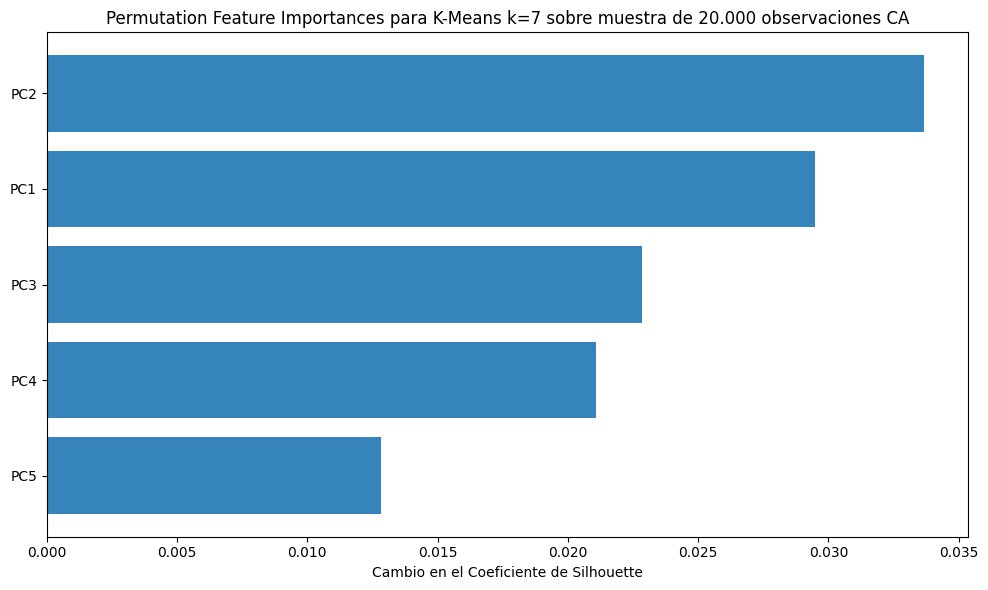

In [38]:
# Nombres de las features (componentes principales)
feature_names_k7 = X_pca_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_k7 = np.argsort(np.abs(p_importance_k7_pca.importances_mean))

# Visualizamos con los atributos ordenados de menor a mayor importancia
plt.figure(figsize=(10, 6))

plt.barh(range(len(feature_names_k7)), p_importance_k7_pca.importances_mean[sorted_indices_perm_k7], alpha=0.9)
plt.yticks(range(len(feature_names_k7)), feature_names_k7[sorted_indices_perm_k7])
plt.title("Permutation Feature Importances para K-Means k=7 sobre muestra de 20.000 observaciones CA")
plt.xlabel("Cambio en el Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

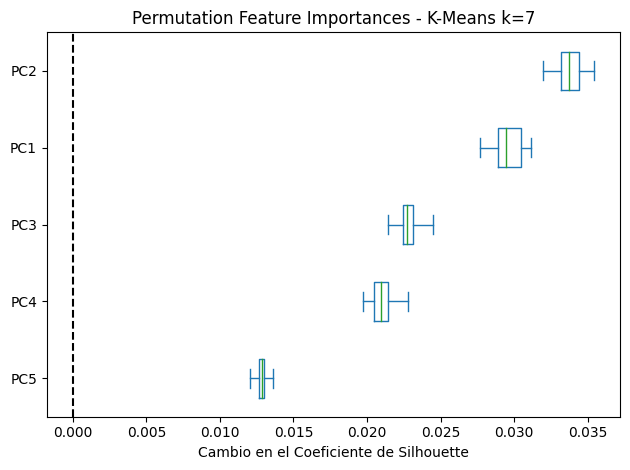

In [39]:
# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_k7 = p_importance_k7_pca.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_k7 = pd.DataFrame(
    p_importance_k7_pca.importances[sorted_importances_idx_k7].T,
    columns=feature_names_k7[sorted_importances_idx_k7],
)
# Construimos el boxplot de la distribución de importancias de cada componente principal
ax = importances_k7.plot.box(vert=False, whis=10)
ax.set_title("Permutation Feature Importances - K-Means k=7")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Cambio en el Coeficiente de Silhouette")
ax.figure.tight_layout()
plt.show()

### 4.1.4 Cálculo de la importancia de variables para K-Means k=7 sobre el conjunto estandarizado

In [40]:
# Muestra representativa para acelerar el cálculo
df_scaled_sample = df_scaled.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=7 sobre datos estandarizados (sin PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_estand.pkl'):
    p_importance_k7_estand = joblib.load('resultados_explicabilidad/p_importance_k7_estand.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_estand = permutation_importance(
        kmeans_k7_estand,
        df_scaled_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

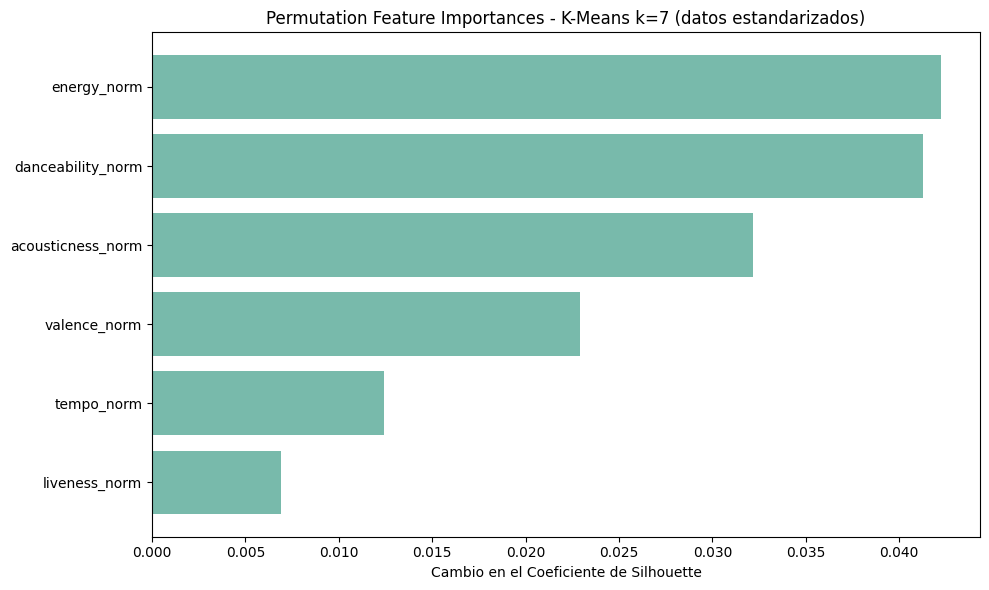

In [41]:
# Nombres de las features (variables estandarizadas)
feature_names_estand = df_scaled_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_estand = np.argsort(np.abs(p_importance_k7_estand.importances_mean))

# Visualizamos con los atributos ordenados de menor a mayor importancia
plt.figure(figsize=(10, 6))

plt.barh(range(len(feature_names_estand)), p_importance_k7_estand.importances_mean[sorted_indices_perm_estand], color='#69B3A2', alpha=0.9)
plt.yticks(range(len(feature_names_estand)), feature_names_estand[sorted_indices_perm_estand])
plt.title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)")
plt.xlabel("Cambio en el Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

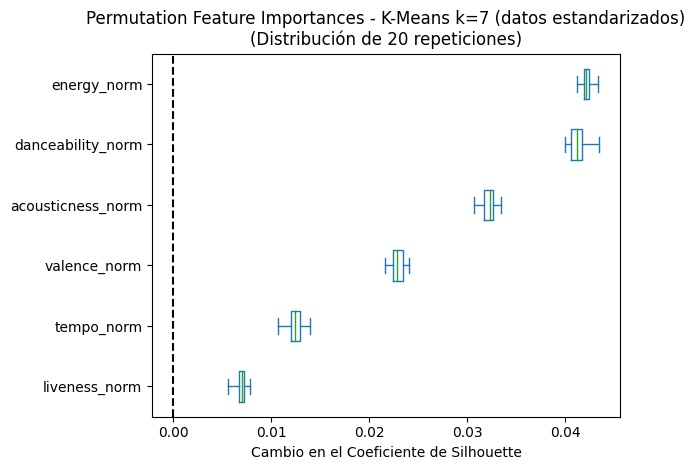

In [42]:
# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_estand = p_importance_k7_estand.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_estand = pd.DataFrame(
    p_importance_k7_estand.importances[sorted_importances_idx_estand].T,
    columns=feature_names_estand[sorted_importances_idx_estand],
)
# Construimos el boxplot de la distribución de importancias de cada variable estandarizada
ax = importances_estand.plot.box(vert=False, whis=10)
ax.set_title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)\n(Distribución de 20 repeticiones)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Cambio en el Coeficiente de Silhouette")
ax.figure.tight_layout()
plt.show()

In [43]:
# Guardado de resultados de Permutation Feature Importance
import os
os.makedirs('resultados_explicabilidad', exist_ok=True)

# Guardar solo los resultados de Permutation Feature Importance
joblib.dump(p_importance_k4_pca, 'resultados_explicabilidad/p_importance_k4_pca.pkl')
joblib.dump(p_importance_k7_pca, 'resultados_explicabilidad/p_importance_k7_pca.pkl')
joblib.dump(p_importance_k7_estand, 'resultados_explicabilidad/p_importance_k7_estand.pkl')

print("Resultados de Permutation Feature Importance guardados correctamente")

Resultados de Permutation Feature Importance guardados correctamente


### 4.1.5 Comparación e interpretación de la importancia de variables

TODO AQUI EXPLICACION

## 4.2 SHAP Values para clustering

### Definición de la función de salida para K-Means (distancias a centroides)

### Cálculo de SHAP Values para K-Means k=4

### Cálculo de SHAP Values para GMM n=20

### Visualización e interpretación de SHAP por clúster
